In [1]:
import torch
import torch.nn as nn
from tqdm import tqdm

from red import UNet3D
from qsmloader import QSMLoader
from torch.utils.data import DataLoader
from utils import plot_3d_medical_image
import matplotlib.pyplot as plt
from loss import quantile_regression_loss_fn
from scipy import io
from utils import continuous_dipole_kernel
import numpy as np

In [2]:
torch.cuda.init()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
data = io.loadmat('F:/data/Cosmos_SNR100.mat')
chi_cosmos = data['chi_cosmos'] * data['mask_use']
mask_cosmos = data['mask_use']

data = io.loadmat('F:/data/evaluation_mask.mat')
eval_mask_cosmos = data['evaluation_mask']

In [4]:

def gen_cosmos(jump=False):
    phase = np.real(np.fft.ifftn(np.fft.fftn(chi_cosmos) * continuous_dipole_kernel(chi_cosmos.shape))) * mask_cosmos

    mag = chi_cosmos - chi_cosmos.min()
    mag = mag / mag.max()
    mag = mag * mask_cosmos

    scale = np.pi / (2 * np.max(np.abs(phase)))
    signal = mag * np.exp(1j * phase * scale)

    snr = np.random.randint(95, 105, (1,))

    signal = signal + ((1. / snr) * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape)))

    phase = np.angle(signal).astype(np.float32) / scale
    phase = phase * mask_cosmos
    if jump:
        phase[80, 80, 80] = 2
        phase[80, 80, 79] = -2

    p = torch.Tensor(phase.copy()).unsqueeze(0).unsqueeze(0)
    return p

In [5]:
def eval_cosmos(recon):
    metrics = {}
    metrics['rmse'] = 100 * np.linalg.norm(recon.ravel() - chi_cosmos.ravel()) / np.linalg.norm(chi_cosmos.ravel())
    for i in range(12):
        sub_mask = eval_mask_cosmos == i
        pred = recon[sub_mask]
        gt = chi_cosmos[sub_mask]
        metrics[f'rmse_zona_{i}'] = 100 * np.linalg.norm(gt - pred) / np.linalg.norm(gt)
        metrics[f'mean_zona_{i}'] = np.mean(pred)
        metrics[f'std_zona_{i}'] = np.std(pred)
    return metrics

In [8]:
files = [f'./saved/checkpoint_epoch_{i}.pth' for i in range(1, 19)] + \
        [f'./saved/checkpoint_epoch_{i}_respaldo.pth' for i in [1, 8]] + \
        [f'./saved/checkpoint_epoch_8_respaldo2.pth']

In [9]:
model_susc = UNet3D(in_channels=1, out_channels=3)
model_susc.load_state_dict(torch.load(files[16], weights_only=True)['model'])

<All keys matched successfully>

In [11]:
def eval_model(model_in, p, mask):
    model_in.eval()
    with torch.inference_mode():
        out = model_in((p).to(device)).cpu() * mask

    output = out * 1
    lam = model_susc.calib_param
    output[:, 0, :, :, :] = torch.minimum(output[:, 0, :, :, :], output[:, 1, :, :, :])
    output[:, 2, :, :, :] = torch.maximum(output[:, 2, :, :, :], output[:, 1, :, :, :])
    upper_edge = lam * (output[:, 2, :, :, :] - output[:, 1, :, :, :]) + output[:, 1, :, :, :]
    prediction = output[:, 1, :, :, :]
    lower_edge = output[:, 1, :, :, :] - lam * (output[:, 1, :, :, :] - output[:, 0, :, :, :])

    upper_edge = upper_edge[0].numpy()
    prediction = prediction[0].numpy()
    lower_edge = lower_edge[0].numpy()
    return upper_edge, prediction, lower_edge

In [10]:
model_susc = model_susc.to(device)

In [12]:
p = gen_cosmos(False)

In [13]:

model_susc.eval()
with torch.inference_mode():
    out = model_susc((p).to(device)).cpu() * mask_cosmos
gt = chi_cosmos * 1.
pred = out[0, 1].numpy() * mask_cosmos
m = mask_cosmos == 1
print(100 * np.linalg.norm(pred.ravel() - gt.ravel()) / np.linalg.norm(gt.ravel()))

33.1096677154623


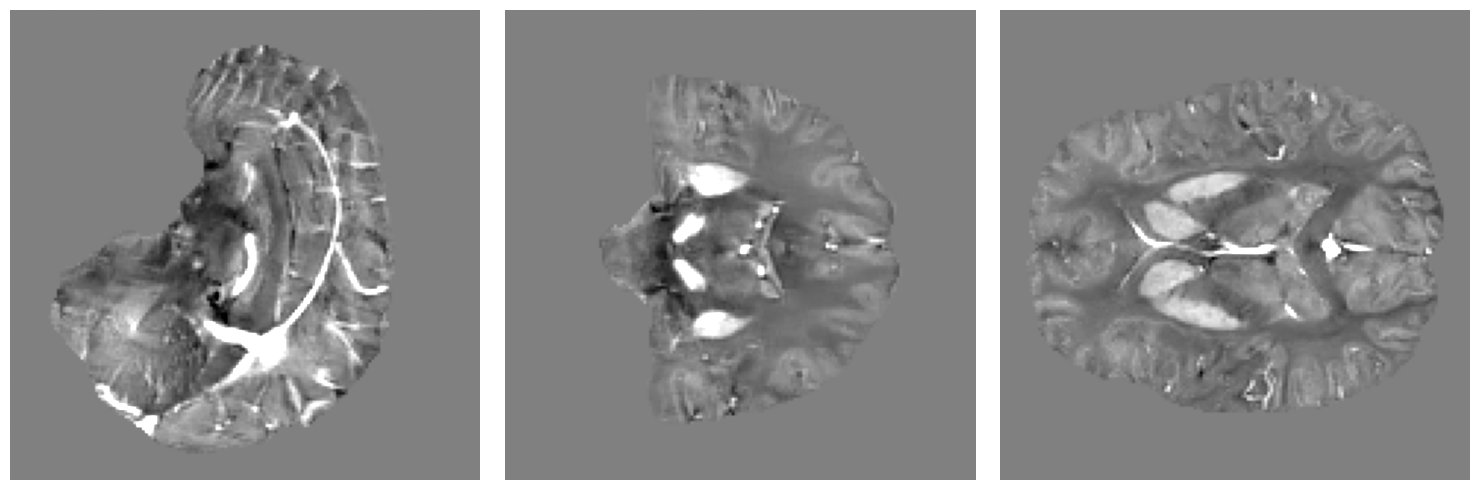

In [14]:
plot_3d_medical_image(pred, rango=(-0.1, 0.1))

In [16]:
def gen_phase(susc): 
    return np.real(np.fft.ifftn(np.fft.fftn(susc) * continuous_dipole_kernel(susc.shape)))

In [17]:
p.squeeze().shape

torch.Size([160, 160, 160])

In [18]:
rp = gen_phase(pred)
pp = p.squeeze()
residual = (pp - rp) * mask_cosmos

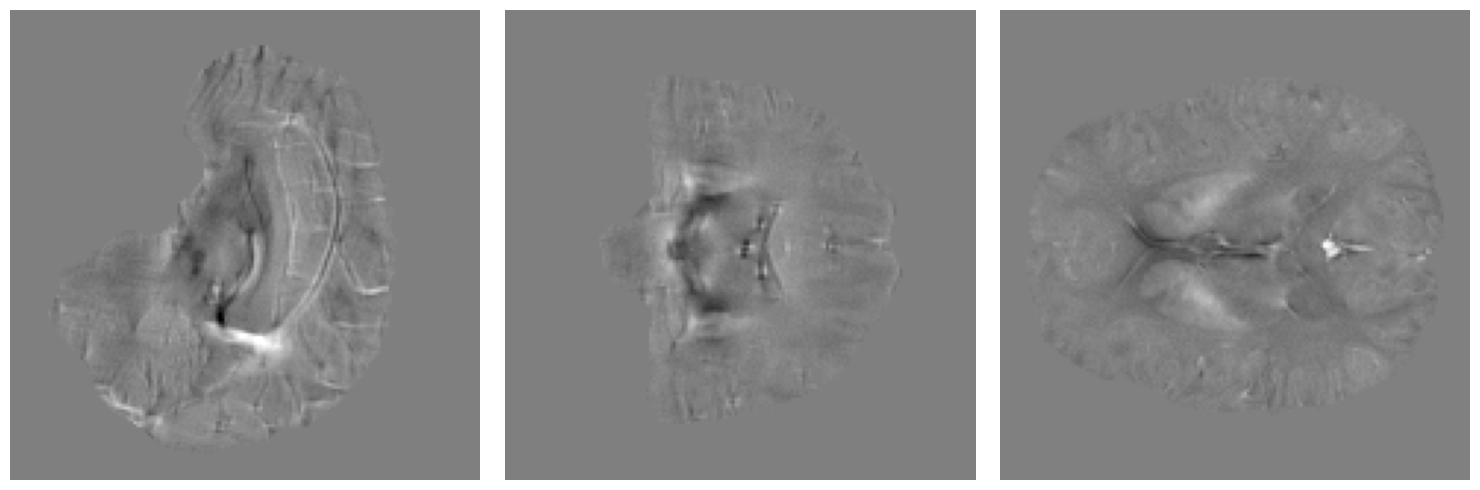

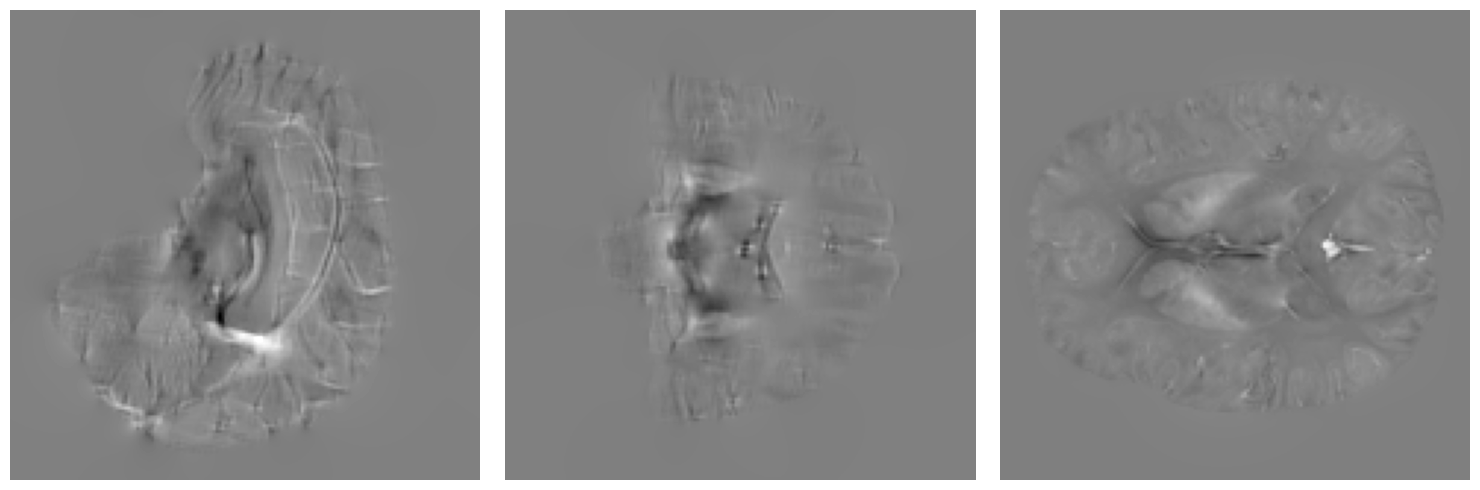

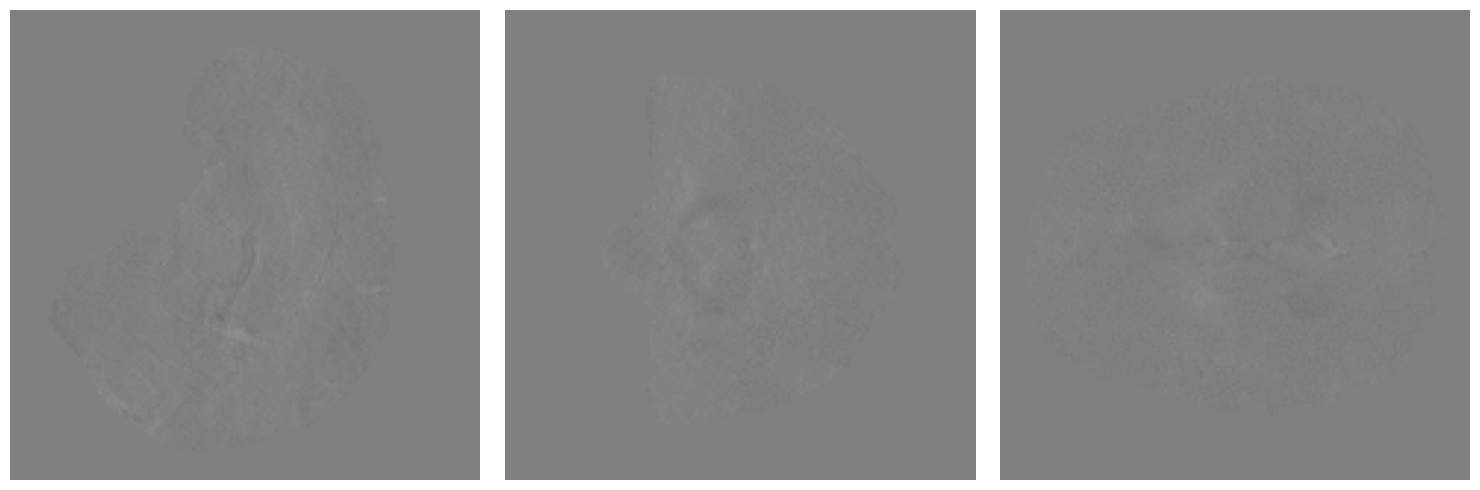

In [19]:

plot_3d_medical_image(pp, rango=(-0.1, 0.1))
plot_3d_medical_image(rp, rango=(-0.1, 0.1))
plot_3d_medical_image(residual, rango=(-0.1, 0.1))

In [27]:
r2 = residual.unsqueeze(0).unsqueeze(0).to(torch.float32)
r2.dtype

torch.float32

96.06970051004241


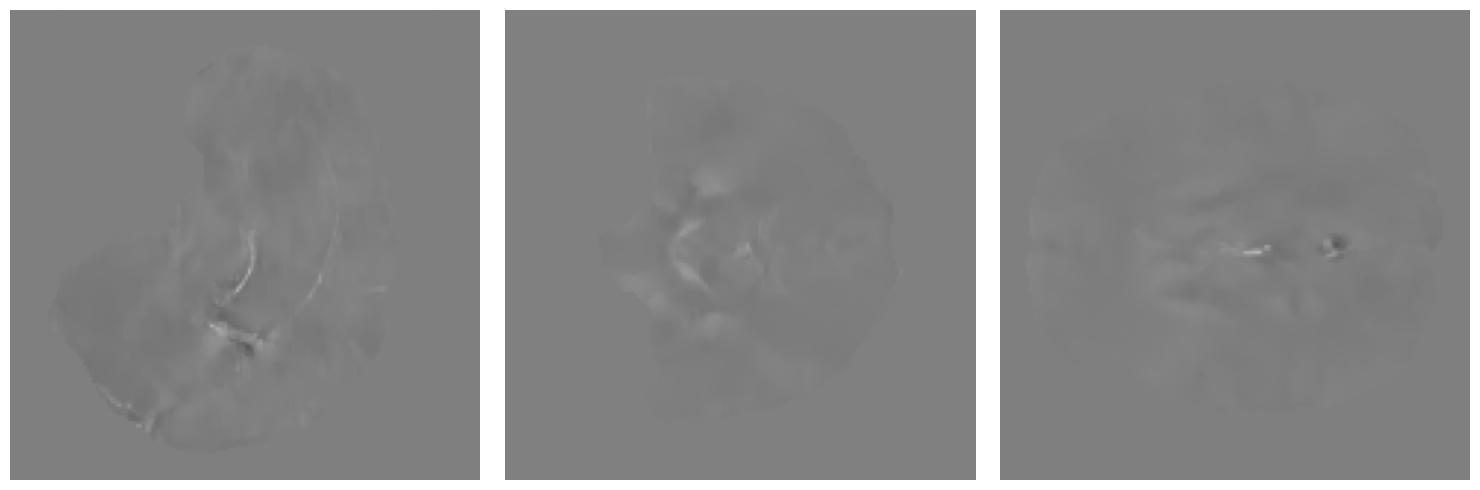

In [28]:
model_susc.eval()
with torch.inference_mode():
    out = model_susc((r2).to(device)).cpu() * mask_cosmos
gt = chi_cosmos * 1.
pred2 = out[0, 1].numpy() * mask_cosmos
m = mask_cosmos == 1
print(100 * np.linalg.norm(pred2.ravel() - gt.ravel()) / np.linalg.norm(gt.ravel()))
plot_3d_medical_image(pred2, rango=(-0.1, 0.1))

29.46748218926423


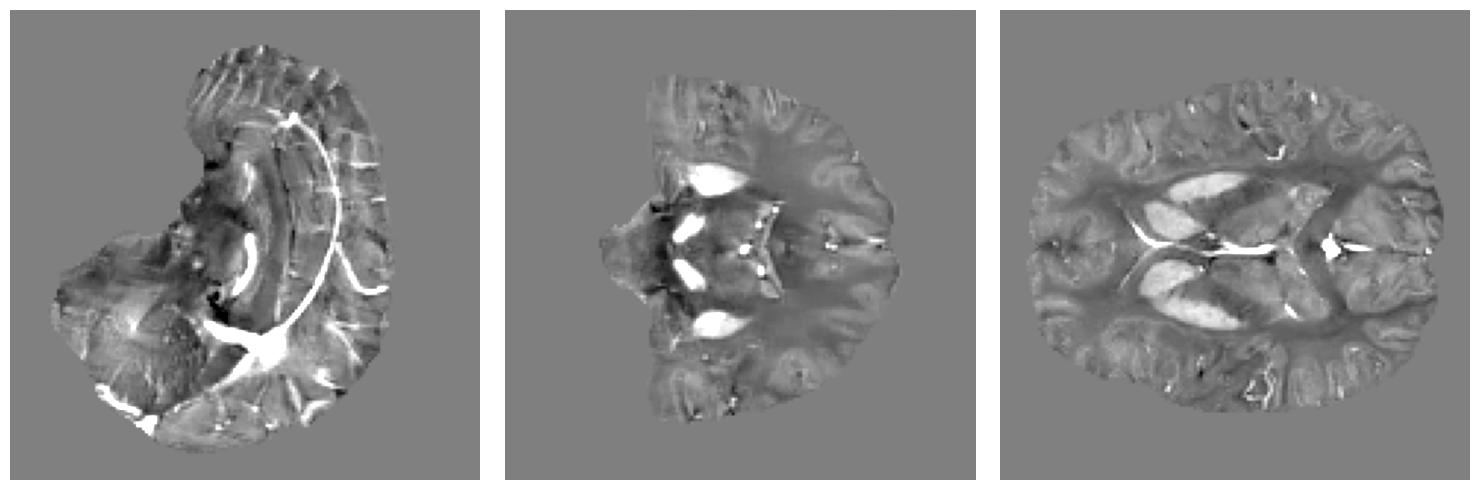

In [29]:
pred3 = pred + pred2

print(100 * np.linalg.norm(pred3.ravel() - gt.ravel()) / np.linalg.norm(gt.ravel()))
plot_3d_medical_image(pred3, rango=(-0.1, 0.1))

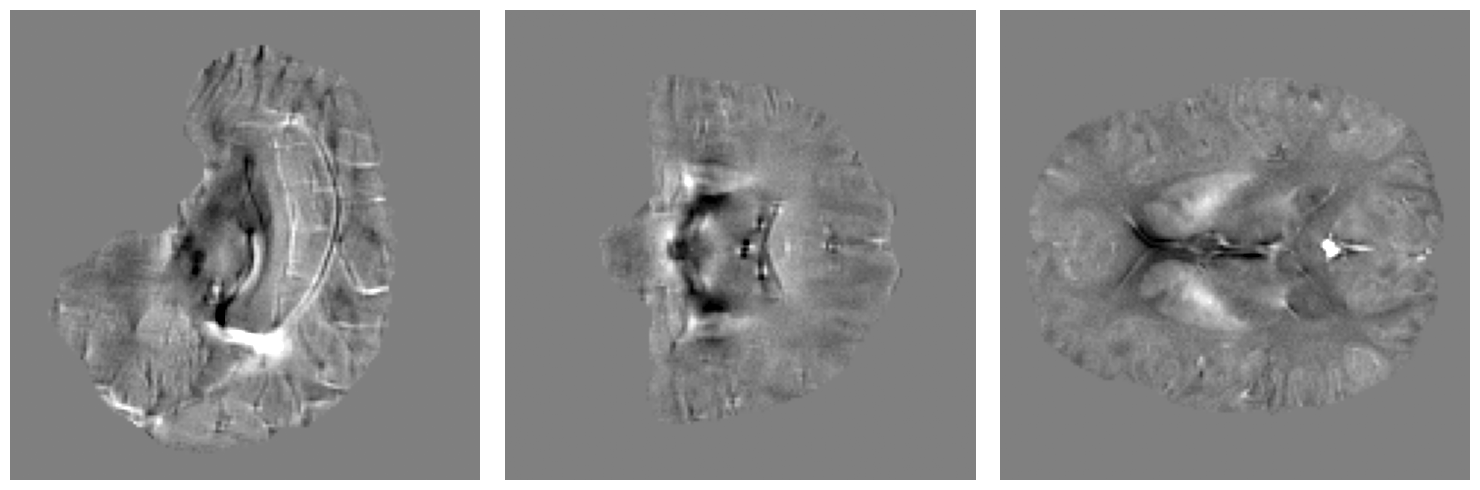

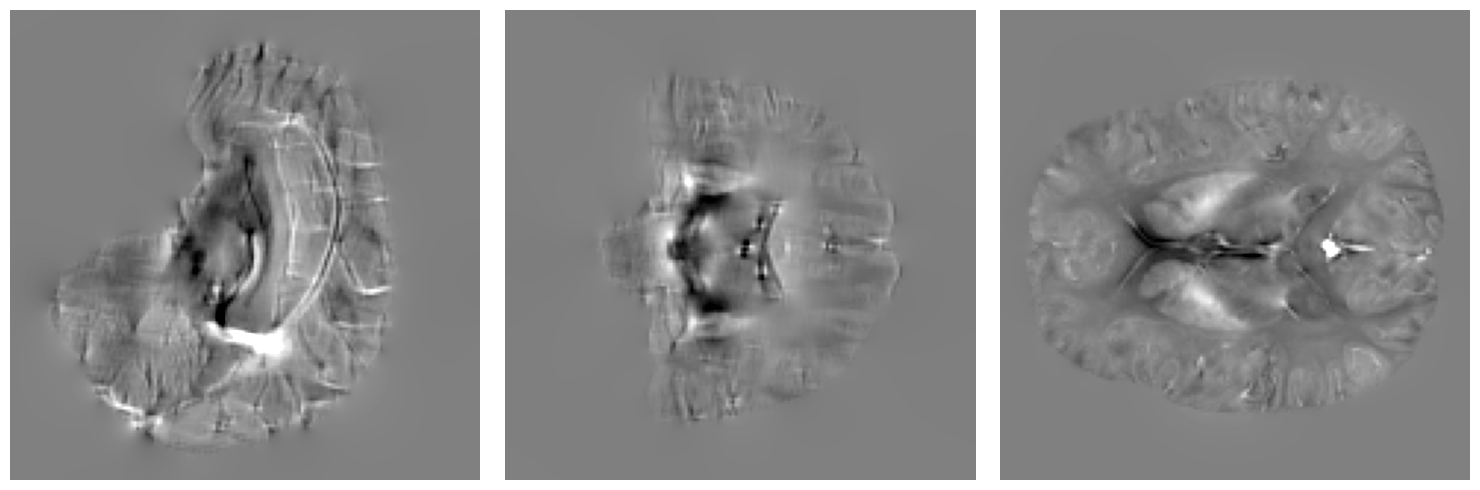

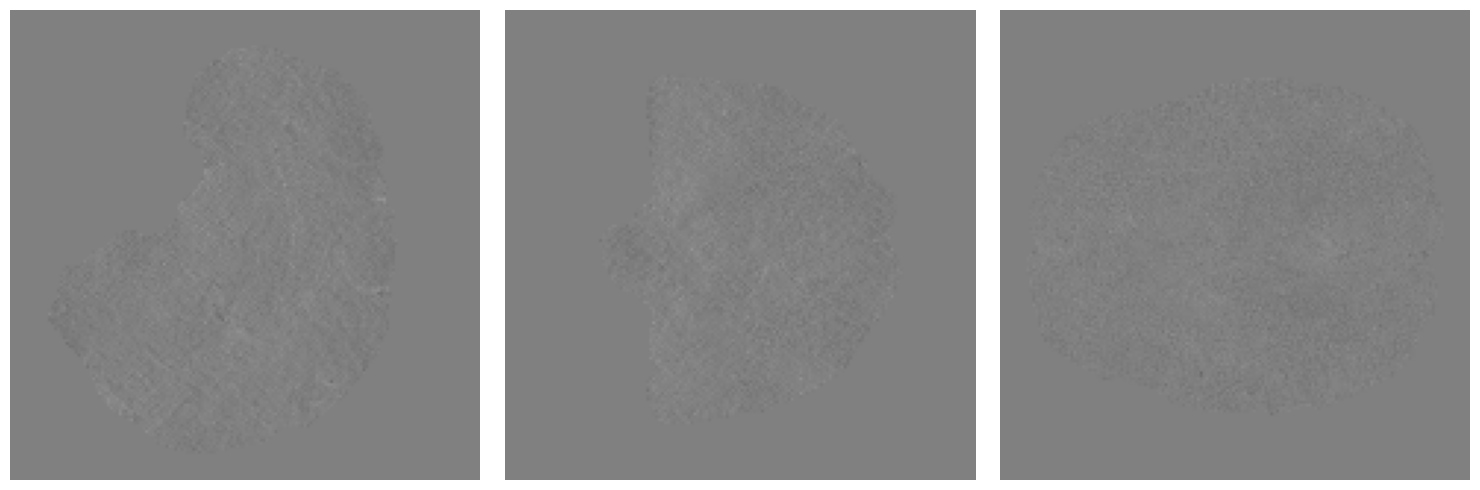

In [30]:
rp = gen_phase(pred3)
pp = p.squeeze()
residual = (pp - rp) * mask_cosmos

plot_3d_medical_image(pp, rango=(-0.05, 0.05))
plot_3d_medical_image(rp, rango=(-0.05, 0.05))
plot_3d_medical_image(residual, rango=(-0.05, 0.05))

In [31]:
r3 = residual.unsqueeze(0).unsqueeze(0).to(torch.float32)
r3.dtype

torch.float32

98.8761761882815


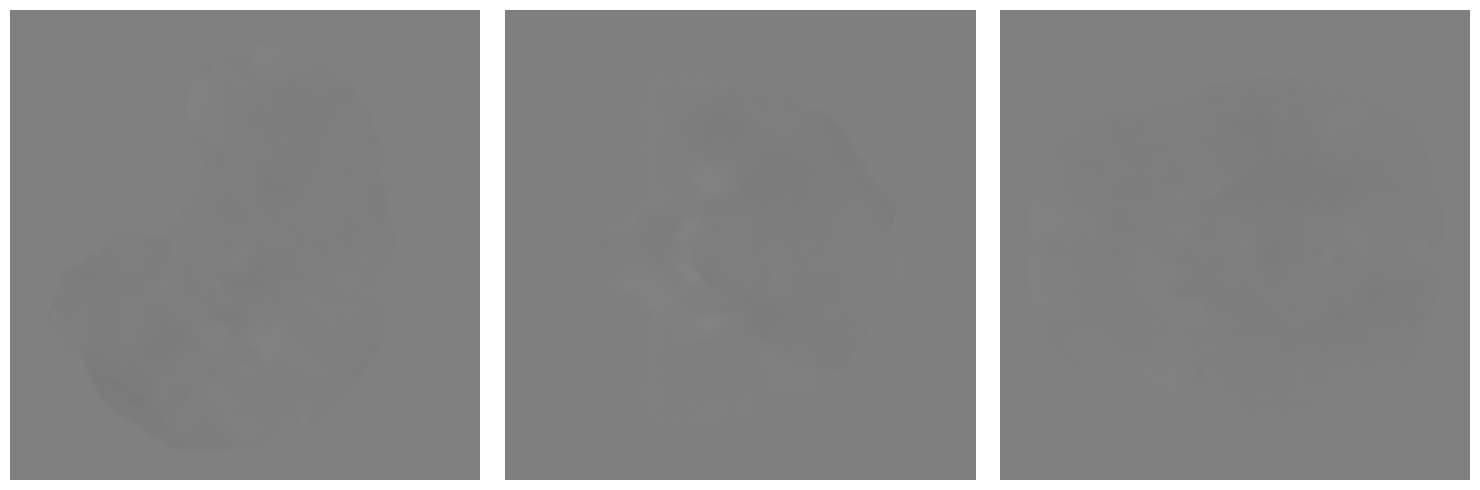

In [32]:
model_susc.eval()
with torch.inference_mode():
    out = model_susc((r3).to(device)).cpu() * mask_cosmos
gt = chi_cosmos * 1.
pred4 = out[0, 1].numpy() * mask_cosmos
m = mask_cosmos == 1
print(100 * np.linalg.norm(pred4.ravel() - gt.ravel()) / np.linalg.norm(gt.ravel()))
plot_3d_medical_image(pred4, rango=(-0.1, 0.1))

29.21785666745117


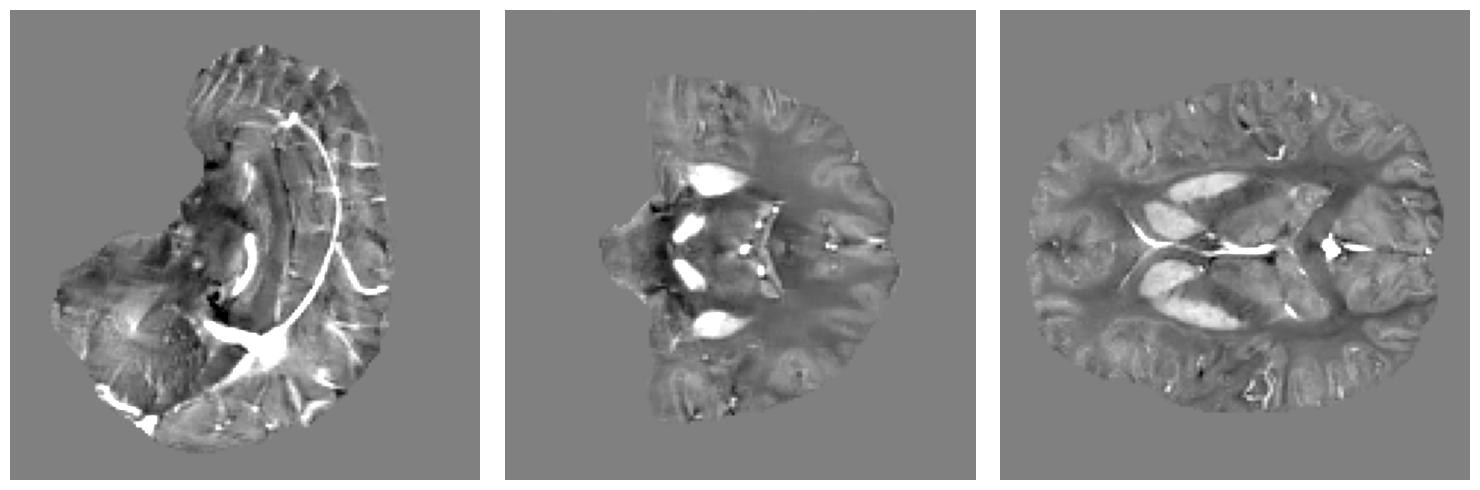

In [34]:
pred5 = pred4 + pred3

print(100 * np.linalg.norm(pred5.ravel() - gt.ravel()) / np.linalg.norm(gt.ravel()))
plot_3d_medical_image(pred5, rango=(-0.1, 0.1))

In [35]:
p.shape

torch.Size([1, 1, 160, 160, 160])

In [50]:
def recon_exp(phase, iters=3): 
    recons = []
    rescon = []
    errores = []
    
    input1 = phase
    qsm_ans = 0
    for i in range(iters):
        model_susc.eval()
        with torch.inference_mode():
            out = model_susc((input1).to(device)).cpu() * mask_cosmos
        gt = chi_cosmos * 1.
        pred = (out[0, 1].numpy()) * mask_cosmos
        rescon.append(pred.copy())
        pred += qsm_ans 
        recons.append(pred.copy())
        print(err:=(100 * np.linalg.norm(pred.ravel() - gt.ravel()) / np.linalg.norm(gt.ravel())))
        errores.append(err)
        qsm_ans = pred.copy()
        
        rp = gen_phase(pred)
        pp = phase.squeeze()
        residual = (pp - rp) * mask_cosmos
        input1 = residual.unsqueeze(0).unsqueeze(0).to(torch.float32)
        
    return recons, rescon, errores

recons, rescon, errores = recon_exp(p, 10)
        

33.1096677154623
29.46748218926423
29.21785666745117
29.645577785763972
30.316050773869552
31.065221683561838
31.819744737668188
32.54488724403884
33.219588855155145
33.84398005141236


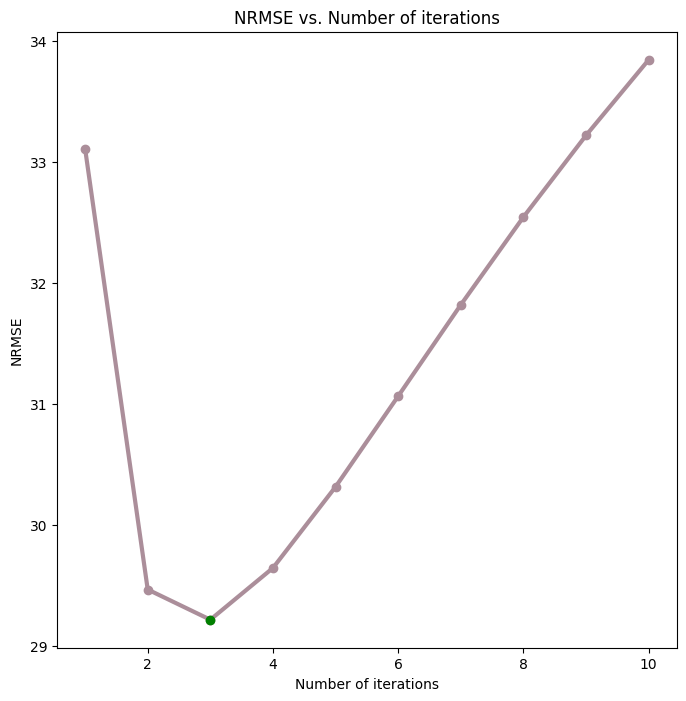

In [48]:
plt.figure(figsize=(8, 8))
plt.plot(_x:=np.arange(1, len(errores) + 1), _y:=errores, 'o-', linewidth=3, color=np.random.rand(3))
idx = np.argmin(_y)
plt.plot(_x[idx], _y[idx], 'o', color='g')
plt.xlabel('Number of iterations')
plt.ylabel('NRMSE')
plt.title('NRMSE vs. Number of iterations')
plt.show()

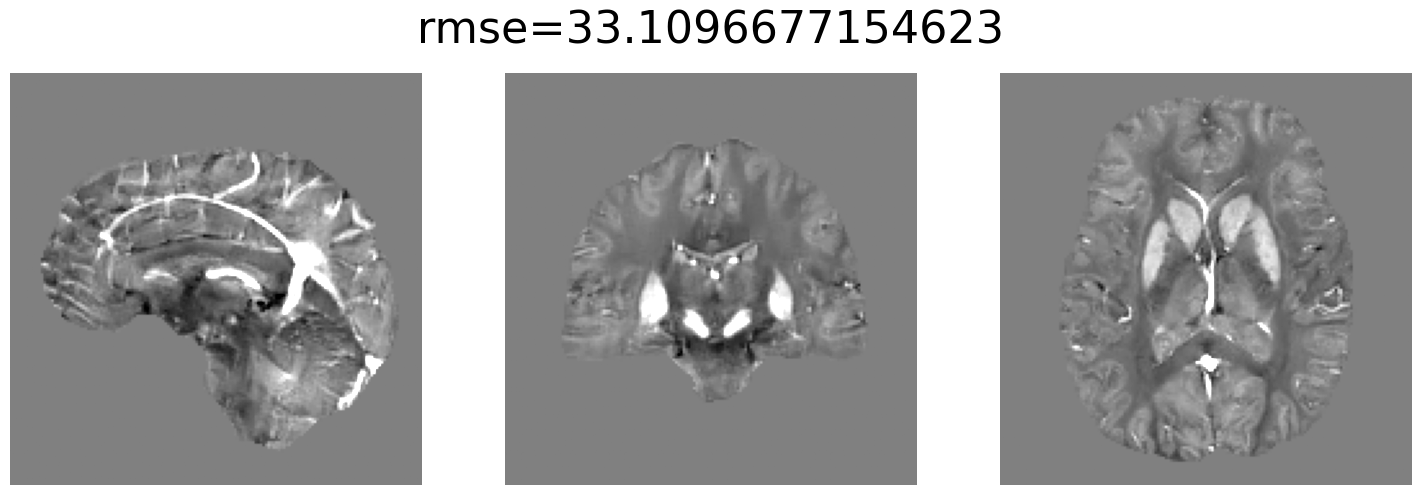

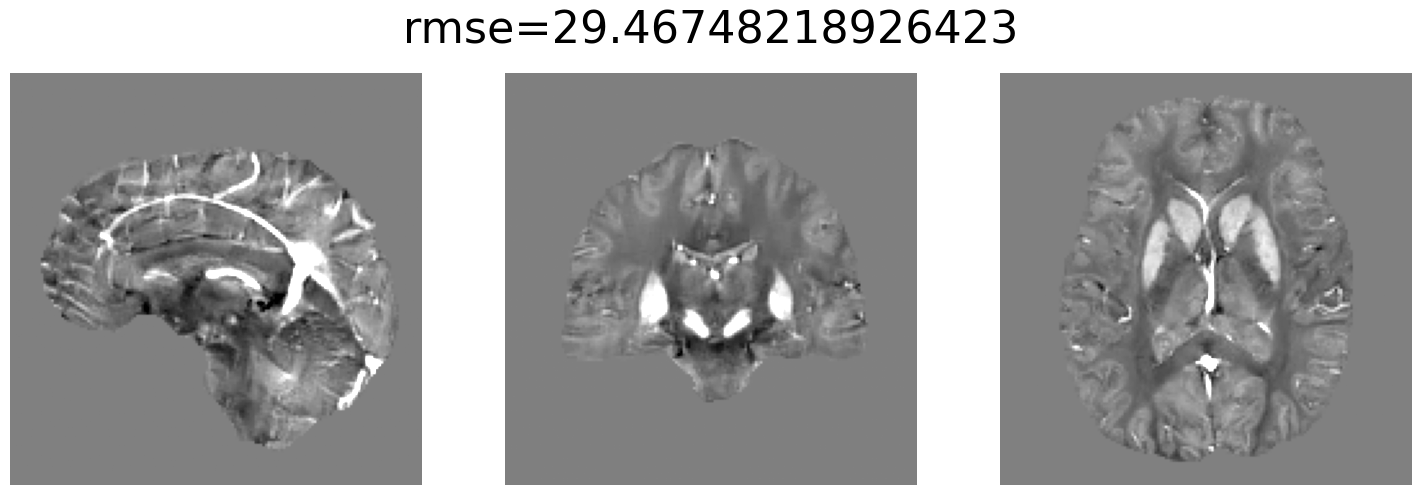

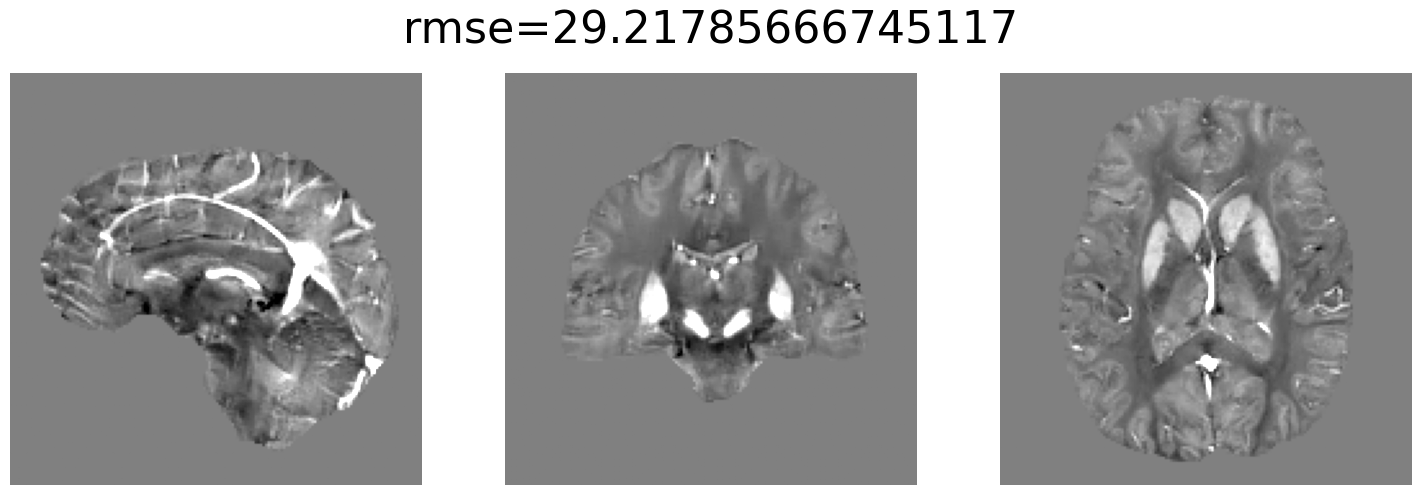

In [57]:
for pred, rmse in zip(recons[:3], errores):
    plot_3d_medical_image(pred, rango=(-0.1, 0.1), title=f'{rmse=}')

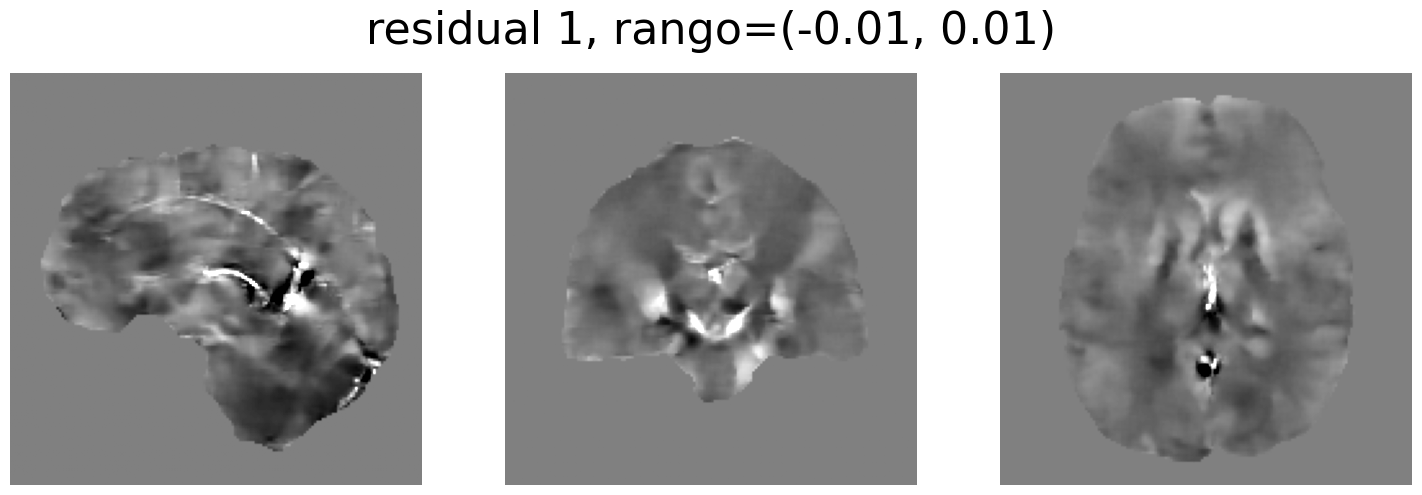

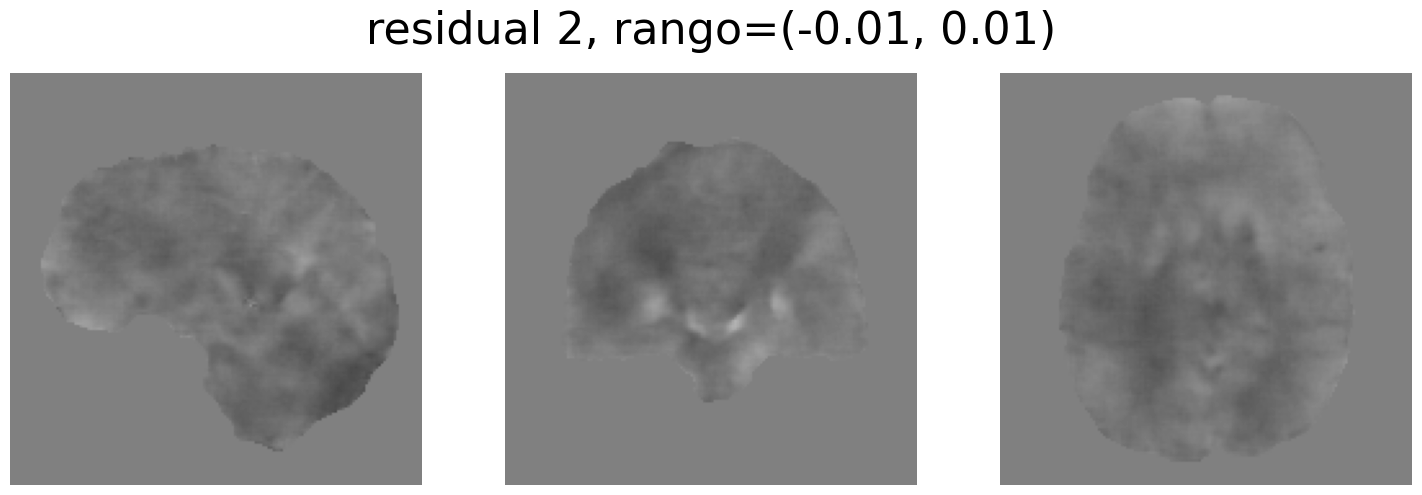

In [59]:
for idx, res in enumerate(rescon[1:3]):
    plot_3d_medical_image(res, rango=(-0.01, 0.01), title=f'residual {idx+1}, rango=(-0.01, 0.01)')

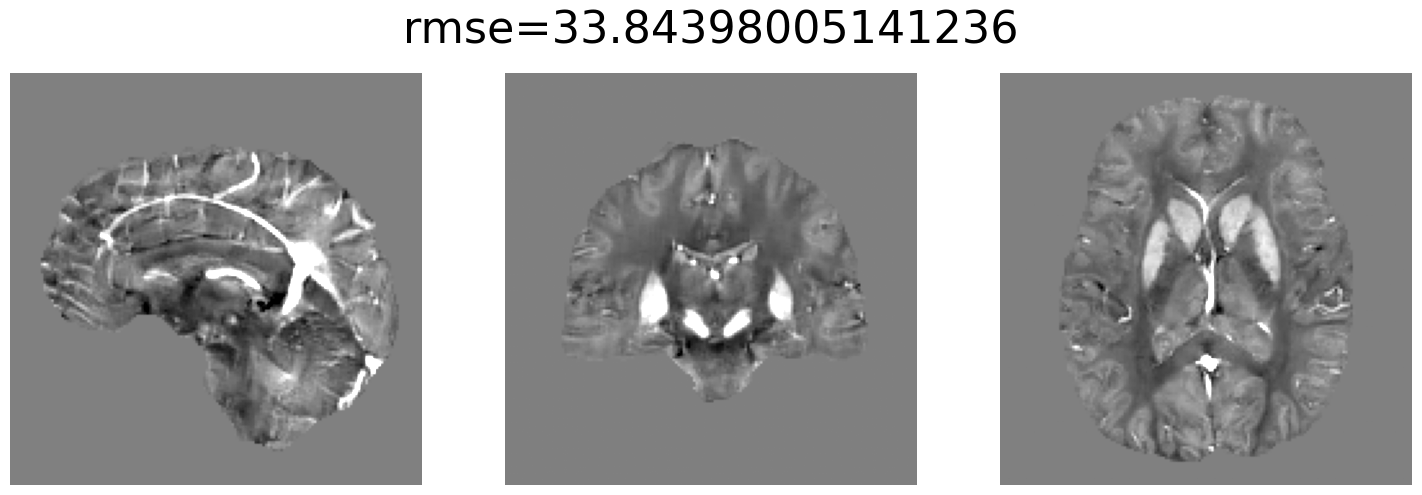

In [61]:
for pred, rmse in zip(recons[-1:], errores[-1:]):
    plot_3d_medical_image(pred, rango=(-0.1, 0.1), title=f'{rmse=}')

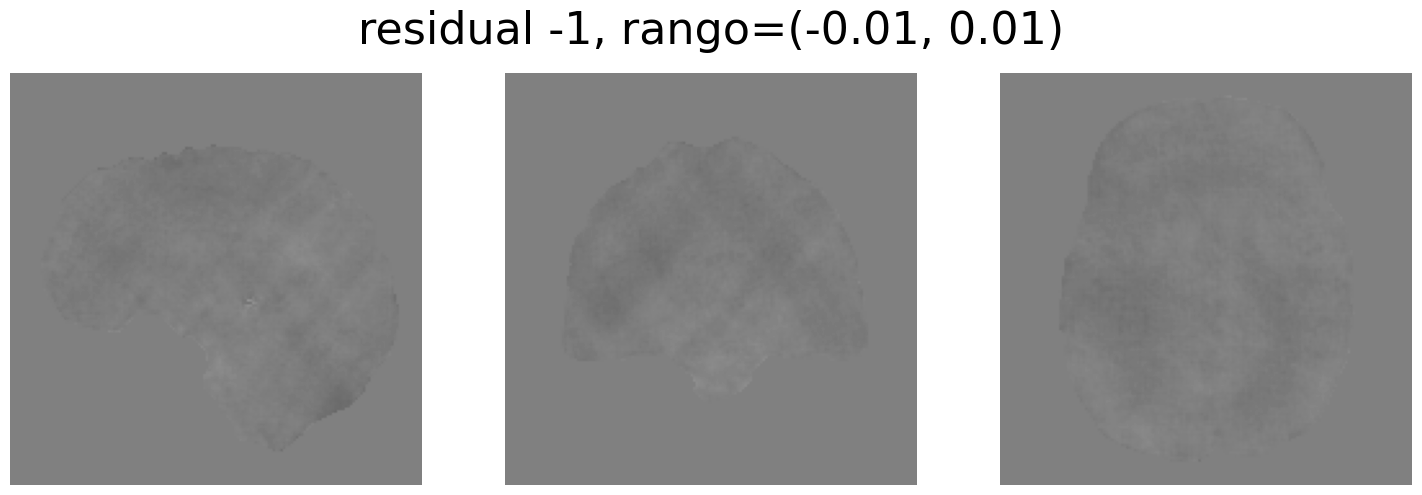

In [62]:
for idx, res in enumerate(rescon[-1:]):
    plot_3d_medical_image(res, rango=(-0.01, 0.01), title=f'residual {-1}, rango=(-0.01, 0.01)')

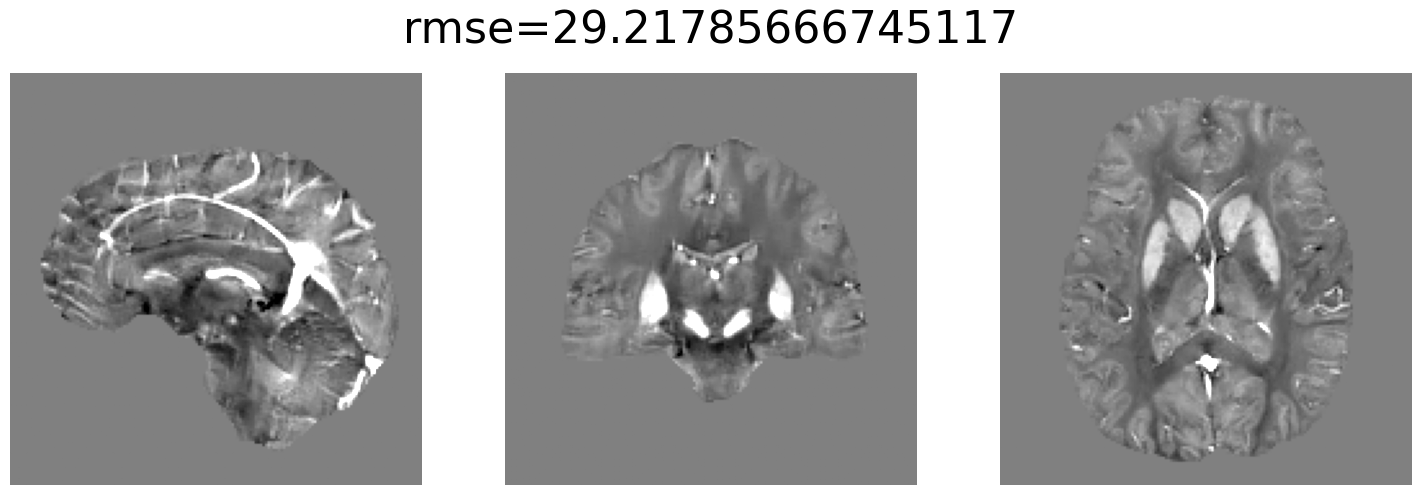

In [56]:

def plot_3d_medical_image(image, title=None, cmap='gray', rango=None):
    """
    Plot a 3D medical image in three views: axial, coronal, and sagittal.

    Parameters:
    - image: 3D numpy array with shape (D, H, W)
    - title: string, optional title for the entire figure
    - cmap: string, colormap to use for the plots (default is 'gray')
    """
    if rango is None:
        rango = (image.min(), image.max())

    D, H, W = image.shape

    # Create a figure with three subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    # Axial view (top-down)
    im1 = image[D // 2, :, :]
    im1 = im1.T
    im1 = im1[::-1, :]
    ax1.imshow(im1, cmap=cmap, aspect='equal', vmin=rango[0], vmax=rango[1])
    # ax1.set_title('Axial View')
    ax1.axis('off')

    # Coronal view (front)
    im2 = image[:, H // 2, :]
    im2 = im2.T
    im2 = im2[::-1, :]
    ax2.imshow(im2, cmap=cmap, aspect='equal', vmin=rango[0], vmax=rango[1])
    # ax2.set_title('Coronal View')
    ax2.axis('off')

    # Sagittal view (side)
    im3 = image[:, :, W // 2]
    im3 = im3.T
    # im3 = im3[::-1, :]
    ax3.imshow(im3, cmap=cmap, aspect='equal', vmin=rango[0], vmax=rango[1])
    # ax3.set_title('Sagittal View')
    ax3.axis('off')

    if title:
        fig.suptitle(title, fontsize=32)

    plt.tight_layout()
    plt.show()
    
plot_3d_medical_image(pred, rango=(-0.1, 0.1), title=f'{rmse=}')